# HWO Background Thermal Model — Study Notebook

**Goal.** Work through how the syotools / hwo-tools ETC implements the *thermal*
(self-emission) background for HWO, starting from the telescope models that were avvailable to me at the time of this work :**EAC1, EAC2, EAC3** . This notebook is a working document, not a polished tutorial:
the intent is to expose the real code paths and the real numbers.

Structure:
1. **Setup** — environment + imports (mirrors the hwo-tools tutorials).
2. **EAC telescope models** — instantiate EAC1 / EAC2 / EAC3, tabulate the
   parameters that feed the thermal background, and compare *as-loaded* values
   against the raw config files.
3. **First look at the thermal model** — locate `Camera.c_thermal` / `Camera.planck`
   and evaluate them for EAC1 as a starting point for the deeper study.

We restrict attention to **EAC1, EAC2, EAC3** further work is necessary to implement EAC5.

AI was used to help create this Notebook

## 1. Setup

syotools needs three environment variables pointing at its reference data and at
the Sci-Eng-Interface (SEI) config tree. We resolve them programmatically from
the installed package locations so the notebook is portable across sessions.
Adjust `SCI_ENG_DIR` if you are pointing at a local clone of `Sci-Eng-Interface`
rather than the installed `hwo_sci_eng` package.

In [3]:
import os

# --- syotools reference data (pysynphot CDBS + syotools data dir) ---
import syotools
_syo_root = os.path.dirname(syotools.__file__)
os.environ.setdefault("SYOTOOLS_DATA_DIR", os.path.join(_syo_root, "reference_data"))
os.environ.setdefault("PYSYN_CDBS",
                      os.path.join(_syo_root, "reference_data", "pysynphot_data"))

# --- Sci-Eng-Interface config tree (telescope + instrument YAMLs) ---
# Prefer a local clone if present, else fall back to the installed package.
# hwo_sci_eng is a namespace package (no __file__), so use __path__.
def _find_sci_eng_dir():
    # 1) explicit env override wins
    if os.environ.get("SCI_ENG_DIR") and os.path.isdir(os.environ["SCI_ENG_DIR"]):
        return os.environ["SCI_ENG_DIR"]
    # 2) common local-clone locations
    candidates = [
        os.path.expanduser("~/Sci-Eng-Interface/hwo_sci_eng"),
        "/",
        os.path.join(os.getcwd(), "Sci-Eng-Interface", "hwo_sci_eng"),
    ]
    # 3) the installed namespace package
    try:
        import hwo_sci_eng
        candidates += list(getattr(hwo_sci_eng, "__path__", []))
    except Exception:
        pass
    for c in candidates:
        if c and os.path.isdir(os.path.join(c, "obs_config", "Tel")):
            return c
    raise RuntimeError("Could not locate Sci-Eng-Interface config tree; "
                       "set SCI_ENG_DIR manually.")

os.environ["SCI_ENG_DIR"] = _find_sci_eng_dir()

for k in ("SYOTOOLS_DATA_DIR", "PYSYN_CDBS", "SCI_ENG_DIR"):
    print(f"{k:18s} = {os.environ[k]}")
    assert os.path.exists(os.environ[k]), f"missing path for {k}"


SYOTOOLS_DATA_DIR  = /Users/lubeda/anaconda3/envs/hwotools/lib/python3.13/site-packages/syotools/reference_data
PYSYN_CDBS         = /grp/hst/cdbs
SCI_ENG_DIR        = /Users/lubeda/anaconda3/envs/hwotools/lib/python3.13/site-packages/hwo_sci_eng


In [4]:
# Core imports. NOTE: synphot may emit 'negative flux/throughput' warnings on
# import as it loads reference throughputs -- these are expected and harmless.
import numpy as np
import pandas as pd
import astropy.units as u
import yaml
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "axes.axisbelow": True,
})

from syotools.models import Telescope, Camera

EACS = ["EAC1", "EAC2", "EAC3"]
print("syotools", getattr(syotools, "__version__", "?"))


  points: [1136.3 1142.3 1142.4 1142.5 1152.7]
  lookup_table: [-9.31015728e-07 -2.34371190e-07 -2.17769838e-06 -1.89383420e-06
 -1.86404638e-07] [synphot.models]
  points: [1170.     1170.5    1171.3    ... 2241.1    2241.2001 2241.3   ]
  lookup_table: [-3.99896421e-07 -3.16809265e-06 -1.49050587e-06 ... -8.56435582e-07
 -9.55618745e-07 -4.15987490e-08] [synphot.models]
  points: [1180.5 1181.5 1241.5 1244.5 1248.5 1249.5 1262.5 1290.5 1307.5 1310.5
 1312.5 1315.5 1316.5 1317.5 1318.5 1321.5 1330.5 1333.5 1341.5 1342.5
 1343.5 1345.5 1346.5 1348.5 1352.5 1370.5 1372.5 1379.5 1380.5 1384.5
 1386.5 1387.5 1388.5 1389.5 1391.5 1395.5 1399.5 1400.5 1426.5 1427.5
 1428.5 1429.5 1434.5 1447.5 1448.5 1449.5 1450.5 1454.5 1455.5 1456.5
 1461.5 1466.5 1474.5 1475.5 1482.5 1493.5 1498.5 1505.5 1519.5 1539.5
 1558.5 1563.5 1567.5 1569.5 1570.5 1575.5 1577.5 1579.5 1581.5 1582.5
 1584.5 1589.5 1590.5 1591.5 1592.5 1594.5 1595.5 1596.5 1599.5 1600.5
 1601.5 1605.5 1606.5 1607.5 1608.5 1609.5 1612

syotools 1.3.5


## 2. EAC telescope models

We load each EAC through the same entry point the ETC uses,
`Telescope.set_from_sei(name)`, and pull out the quantities that actually enter
the thermal-background calculation:

- **effective aperture** `D` and **total collecting area** — set the photon
  collecting power (thermal counts scale as $\propto D^2$).
- **OTA emissivity** $\varepsilon$ — multiplies the Planck emission.
- **temperature** $T$ — sets the Planck spectrum $B_\lambda(T)$.

Note up front: `temperature` and `ota_emissivity` are **not** stored in the EAC
YAMLs — syotools supplies them from its generic `model_defaults.yaml`, so all
three EACs currently inherit the *same* thermal assumptions (270 K, 0.24). Only
the aperture differs between them in this toolchain.

In [5]:
def load_eac(name):
    'Instantiate a Telescope from SEI and return it (as the ETC would).'
    tel = Telescope()
    tel.set_from_sei(name)
    return tel

def as_loaded_params(tel):
    'Extract thermal-relevant parameters from a loaded Telescope object.'
    def _val(x):
        # syotools stores many attrs as [value, unit] lists
        return x[0] if isinstance(x, (list, tuple)) else x
    return {
        "D_eff [m]":        round(float(tel.effective_aperture.to_value(u.m)), 4),
        "area [m^2]":       round(float(tel.total_collecting_area.to_value(u.m**2)), 3),
        "unobscured":       round(float(tel.unobscured_fraction), 4),
        "segmentation":     _val(tel.pm.get("segmentation")),
        "obscuration":      _val(tel.pm.get("obscuration_ratio")),
        "temp [K]":         _val(getattr(tel, "temperature", None)),
        "emissivity":       _val(getattr(tel, "ota_emissivity", None)),
    }

loaded = {e: as_loaded_params(load_eac(e)) for e in EACS}
df_loaded = pd.DataFrame(loaded).T
df_loaded.index.name = "as loaded via set_from_sei"
df_loaded


,D_eff [m],area [m^2],unobscured,segmentation,obscuration,temp [K],emissivity
as loaded via set_from_sei,,,,,,,
EAC1,6.5405,33.598,1.0,hex,0,270.0,0.24
EAC2,6.0,28.274,1.0,keystone,0,270.0,0.24
EAC3,6.0,28.274,1.0,keystone,0,270.0,0.24


### 2a. Cross-check against the raw config files

The loader is a black box; let's read the YAMLs on disk directly and compare.
This is exactly the kind of check a study notebook should do — and here it
catches a real discrepancy for EAC3.

In [6]:
tel_dir = os.path.join(os.environ["SCI_ENG_DIR"], "obs_config", "Tel")

# The finalized EAC1 file plus the two drafts are what actually exist on disk.
yaml_files = {
    "EAC1": "EAC1.yaml",
    "EAC2": "EAC2_draft.yaml",
    "EAC3": "EAC3_draft.yaml",
}

def raw_params(fname):
    with open(os.path.join(tel_dir, fname)) as f:
        d = yaml.safe_load(f)
    pm = d["PM"]
    return {
        "inscribing_D [m]":    pm["inscribing_diameter"][0],
        "circumscribing_D [m]": pm["circumscribing_diameter"][0],
        "obscuration":         pm["obscuration_ratio"][0],
        "segmentation":        pm["segmentation"][0],
    }

df_raw = pd.DataFrame({e: raw_params(f) for e, f in yaml_files.items()}).T
df_raw.index.name = "raw YAML on disk"
df_raw


,inscribing_D [m],circumscribing_D [m],obscuration,segmentation
raw YAML on disk,,,,
EAC1,5.976938,7.225765,0,hex
EAC2,6.0,6.0,0,keystone
EAC3,8.0,8.0,0.2,keystone


### 2b. ⚠️ Known loader bug for EAC3

Compare the two tables above. **EAC3 loads as a 6.0 m keystone with zero
obscuration — i.e. identical to EAC2 — even though `EAC3_draft.yaml` describes an
8.0 m on-axis design with 0.2 obscuration.**

The cause is a copy-paste error in the SEI path table
(`hwo_sci_eng/utils/read_yaml.py`):

```python
paths = {
    "eac1": "/obs_config/Tel/EAC1.yaml",
    "eac2": "/obs_config/Tel/EAC2_draft.yaml",
    "eac3": "/obs_config/Tel/EAC2_draft.yaml",   # <-- should be EAC3_draft.yaml
    ...
}
```

So `read_hwo('eac3')` silently opens the EAC2 file. **Any thermal-background
result generated for "EAC3" is actually EAC2 until this is patched.**

The cell below applies a *local, in-memory* patch (it does not modify the repo)
so that EAC3 loads its true parameters for the remainder of this notebook. It is
guarded so re-running is safe. Comment it out if you want to reproduce the
upstream (buggy) behaviour.

In [7]:
# Local, in-memory fix for the EAC3 -> EAC2 pointer bug.
from hwo_sci_eng.utils import read_yaml

_correct_eac3 = "/obs_config/Tel/EAC3_draft.yaml"
if read_yaml.paths.get("eac3") != _correct_eac3:
    _old = read_yaml.paths.get("eac3")
    read_yaml.paths["eac3"] = _correct_eac3
    print(f"patched read_yaml.paths['eac3']: {_old}  ->  {_correct_eac3}")
else:
    print("read_yaml.paths['eac3'] already correct; nothing to do.")

# Re-load and confirm EAC3 now reflects the 8 m on-axis design.
df_fixed = pd.DataFrame(
    {e: as_loaded_params(load_eac(e)) for e in EACS}
).T
df_fixed.index.name = "as loaded (EAC3 patched)"
df_fixed


patched read_yaml.paths['eac3']: /obs_config/Tel/EAC2_draft.yaml  ->  /obs_config/Tel/EAC3_draft.yaml


,D_eff [m],area [m^2],unobscured,segmentation,obscuration,temp [K],emissivity
as loaded (EAC3 patched),,,,,,,
EAC1,6.5405,33.598,1.0,hex,0,270.0,0.24
EAC2,6.0,28.274,1.0,keystone,0,270.0,0.24
EAC3,8.0,50.265,0.8,keystone,0.2,270.0,0.24


## 3. First look at the thermal background model

The camera thermal self-emission is implemented in
`syotools/models/camera.py`:

- **`Camera.planck`** — evaluates the Planck spectrum $B_\lambda(T)$ at each
  band's pivot wavelength, at the *telescope* temperature, returning
  erg s⁻¹ cm⁻³ sr⁻¹.
- **`Camera.c_thermal`** — converts that to a detector count rate:

$$
C_\mathrm{thermal} \;=\; \varepsilon \,\frac{B_\lambda(T)}{E_\mathrm{phot}}\;
\Big(\tfrac{\pi}{4}D^2\Big)\, \mathrm{QE}\;\Omega\;\Delta\lambda
$$

where $\varepsilon$ is the OTA emissivity, $D$ the effective aperture, $\Omega$
the solid angle of the S/N box, and $\Delta\lambda$ the band width.

Below we wire an HRI camera onto EAC1 and evaluate both, per band, as a
starting point. This is the object we will dissect in later cells (term by term,
and across EAC1/2/3 and temperature).

In [8]:
def build_camera_on(eac_name):
    'Attach an HRI camera to a given EAC telescope.'
    tel = load_eac(eac_name)
    cam = Camera()
    cam.set_from_sei("HRI")
    tel.add_camera(cam)
    return tel, cam

tel1, hri1 = build_camera_on("EAC1")

# Band centres for reference
pivotwave, bandpass = hri1.recover("pivotwave", "derived_bandpass")
pivots = pivotwave[0] * u.Unit(pivotwave[1])

# Planck emission and thermal count rate per band (verbose off)
planck = hri1.planck
thermal = hri1.c_thermal(verbose=False)

df_thermal = pd.DataFrame({
    "band":            hri1.bandnames,
    "pivot [nm]":      np.round(pivots.to_value(u.nm), 1),
    "B_lambda(T)":     [f"{float(x):.3e}" for x in planck.value],
    "c_thermal [{}]".format(thermal.unit): [f"{float(x):.3e}" for x in thermal.value],
})
print("Telescope T =", getattr(tel1, "temperature", None),
      "| emissivity =", getattr(tel1, "ota_emissivity", None))
df_thermal


Telescope T = [270.0, 'K'] | emissivity = [0.24, '']


,band,pivot [nm],B_lambda(T),c_thermal [electron / s]
0,FUV,225.0,2.875e-85,7.070e-89
1,NUV,275.0,5.297e-67,2.180e-70
2,U,336.0,3.691e-52,3.543e-55
3,B,475.0,9.354e-33,2.163e-35
4,V,606.0,9.425e-23,4.491e-25
5,R,775.0,5.860e-15,8.118e-17
6,I,850.0,1.593e-12,2.141e-14
7,J,1260.0,1.610e-04,2.150e-05
8,H,1600.0,3.901e-01,1.493e-01
9,K,2220.0,8.309e+02,1.134e+03


### 3a. Thermal count rate for EAC1 / EAC2 / EAC3

We now evaluate `c_thermal` for all three EACs (with the EAC3 patch from
section 2b active, so EAC3 is the true 8 m design). Same HRI camera, same
bands.

**Result, stated up front:** the per-band thermal count rate is *identical*
across the three EACs, to machine precision — even though their apertures differ
by up to a factor 1.5 in area. This is not because temperature and emissivity
are shared (though they are); it is a genuine geometric cancellation explained in
3b. The table below shows the three columns coming out equal; the ratio table
that follows confirms it is exactly 1.0 in every band.

In [9]:
# Evaluate c_thermal per band for each EAC (patched EAC3).
thermal_by_eac = {}
aperture_by_eac = {}
for e in EACS:
    tel, cam = build_camera_on(e)
    thermal_by_eac[e] = cam.c_thermal(verbose=False)
    aperture_by_eac[e] = float(tel.effective_aperture.to_value(u.m))

# Common band info (identical across EACs)
bands = hri1.bandnames
pivots_nm = pivots.to_value(u.nm)

# Build the comparison table
tbl = {"band": bands, "pivot [nm]": np.round(pivots_nm, 1)}
for e in EACS:
    tbl[f"{e} [e/s]"] = [f"{float(x):.3e}" for x in thermal_by_eac[e].value]
df_eac_thermal = pd.DataFrame(tbl)

print("Effective apertures:",
      {e: round(aperture_by_eac[e], 3) for e in EACS}, "m")
print("D^2 ratios vs EAC1:",
      {e: round((aperture_by_eac[e]/aperture_by_eac['EAC1'])**2, 3) for e in EACS})
df_eac_thermal


Effective apertures: {'EAC1': 6.541, 'EAC2': 6.0, 'EAC3': 8.0} m
D^2 ratios vs EAC1: {'EAC1': 1.0, 'EAC2': 0.842, 'EAC3': 1.496}


,band,pivot [nm],EAC1 [e/s],EAC2 [e/s],EAC3 [e/s]
0,FUV,225.0,7.070e-89,7.070e-89,7.070e-89
1,NUV,275.0,2.180e-70,2.180e-70,2.180e-70
2,U,336.0,3.543e-55,3.543e-55,3.543e-55
3,B,475.0,2.163e-35,2.163e-35,2.163e-35
4,V,606.0,4.491e-25,4.491e-25,4.491e-25
5,R,775.0,8.118e-17,8.118e-17,8.118e-17
6,I,850.0,2.141e-14,2.141e-14,2.141e-14
7,J,1260.0,2.150e-05,2.150e-05,2.150e-05
8,H,1600.0,1.493e-01,1.493e-01,1.493e-01
9,K,2220.0,1.134e+03,1.134e+03,1.134e+03


The `D^2 ratios vs EAC1` printed above are *not* 1 (they are 0.84 and
1.50) — yet the thermal count rates are equal. So the collecting-area factor is
clearly being cancelled by something. The ratio table below divides each EAC by
EAC1 and confirms the thermal rate is aperture-independent: every entry is
1.0.

In [10]:
# Ratio of each EAC's thermal rate to EAC1, per band -> should be flat.
ratio_tbl = {"band": bands, "pivot [nm]": np.round(pivots_nm, 1)}
for e in EACS:
    r = (thermal_by_eac[e].value / thermal_by_eac["EAC1"].value)
    ratio_tbl[f"{e}/EAC1"] = np.round(r, 4)
df_ratio = pd.DataFrame(ratio_tbl)
df_ratio


,band,pivot [nm],EAC1/EAC1,EAC2/EAC1,EAC3/EAC1
0,FUV,225.0,1.0,1.0,1.0
1,NUV,275.0,1.0,1.0,1.0
2,U,336.0,1.0,1.0,1.0
3,B,475.0,1.0,1.0,1.0
4,V,606.0,1.0,1.0,1.0
5,R,775.0,1.0,1.0,1.0
6,I,850.0,1.0,1.0,1.0
7,J,1260.0,1.0,1.0,1.0
8,H,1600.0,1.0,1.0,1.0
9,K,2220.0,1.0,1.0,1.0


### 3b. Comparison plots across the three EACs

**Why the aperture cancels.** The thermal count rate per S/N box is

$$
C_\mathrm{thermal} \;\propto\; \underbrace{\tfrac{\pi}{4}D^2}_{\text{collecting area}}\;\times\;\underbrace{\Omega_\mathrm{box}}_{\text{solid angle of S/N box}} .
$$

The HRI is Nyquist-sampled to the diffraction limit, so from `Camera.pixel_size`
the plate scale is $\text{pixel} = 0.5\,\lambda_\mathrm{fid}/D \propto 1/D$. The
S/N box measured *in pixels* is aperture-invariant (both the PSF FWHM and the
pixel scale $\propto 1/D$, so their ratio is fixed), hence its physical solid
angle $\Omega_\mathrm{box} = \text{pixel}^2 \times N_\mathrm{pix} \propto 1/D^2$.
The product $D^2 \times \Omega_\mathrm{box}$ is therefore **constant** — a larger
telescope collects more thermal photons but funnels them into a proportionally
smaller resolution element, and per resolution element the two exactly cancel.

Three panels below. **Left:** absolute thermal count rate vs wavelength — the
three EACs lie exactly on top of one another (only one curve is visible), over a
background that is negligible in the UV/optical and explodes through the
near-IR. **Middle:** the cancellation itself, at K band — collecting area
$\propto D^2$ rises with aperture, box solid angle $\propto 1/D^2$ falls, and
their product is flat. **Right:** the thermal rate ÷ EAC1, flat at 1.0, the
direct statement that aperture does not enter.

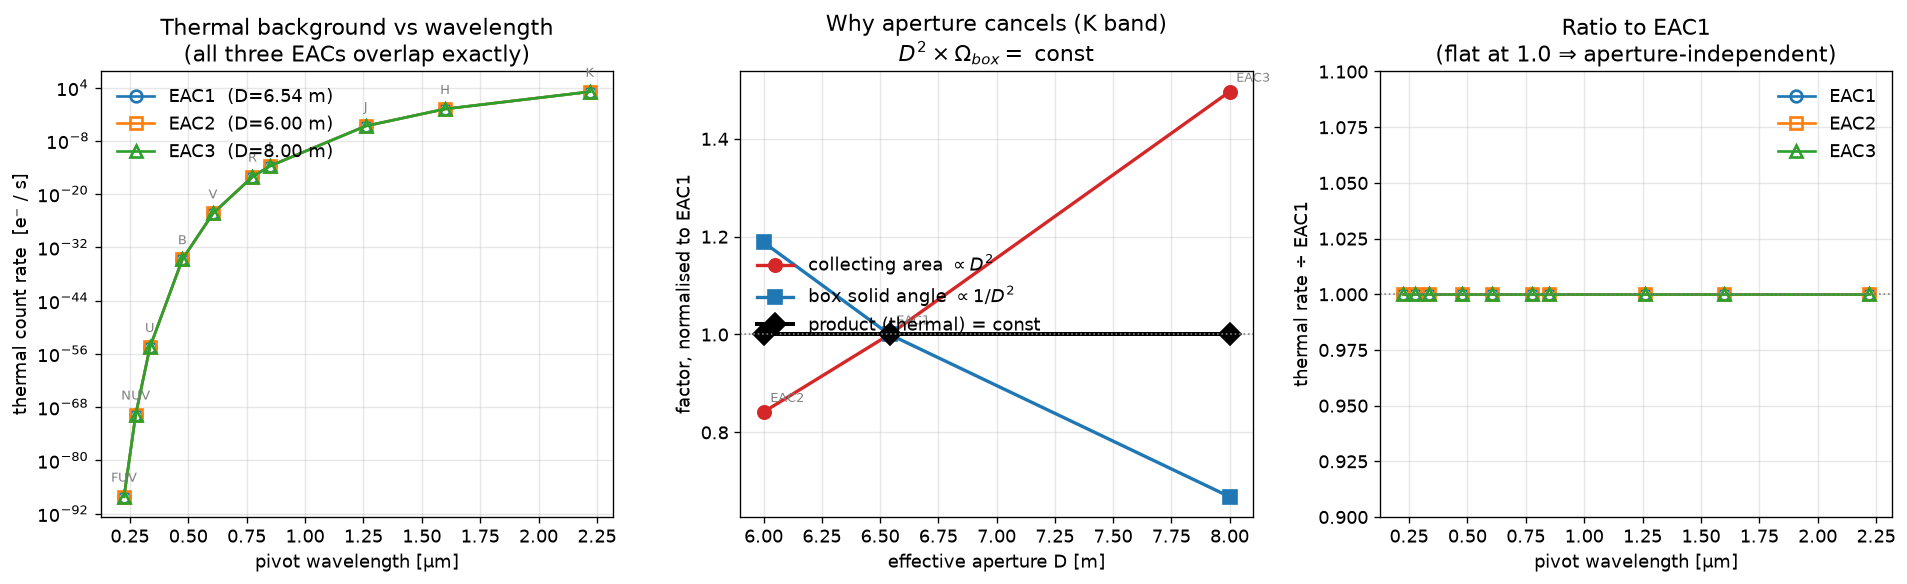

In [11]:
import astropy.units as u

fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(16, 5))
colors = {"EAC1": "#1f77b4", "EAC2": "#ff7f0e", "EAC3": "#2ca02c"}
markers = {"EAC1": "o", "EAC2": "s", "EAC3": "^"}
pivots_um = pivots_nm / 1000.0

# --- Left: absolute thermal count rate vs wavelength (curves overlap) ---
for e in EACS:
    axL.semilogy(pivots_um, thermal_by_eac[e].value, markers[e] + "-",
                 color=colors[e], lw=1.6, ms=7, mfc="none", mew=1.6,
                 label=f"{e}  (D={aperture_by_eac[e]:.2f} m)")
for x, b in zip(pivots_um, bands):
    axL.annotate(b, (x, thermal_by_eac["EAC1"].value[list(bands).index(b)]),
                 textcoords="offset points", xytext=(0, 9),
                 ha="center", fontsize=8, color="gray")
axL.set_xlabel("pivot wavelength [µm]")
axL.set_ylabel("thermal count rate  [e⁻ / s]")
axL.set_title("Thermal background vs wavelength\n(all three EACs overlap exactly)")
axL.legend(frameon=False, loc="upper left")

# --- Middle: the D^2 vs 1/D^2 cancellation, evaluated at K band ---
kidx = list(bands).index("K")
Dm = np.array([aperture_by_eac[e] for e in EACS])          # m
order = np.argsort(Dm); Dm_s = Dm[order]
E_s = [EACS[i] for i in order]

area = np.pi / 4.0 * Dm_s**2                                # collecting area (m^2)
# box solid angle per EAC at K band: pixel_size^2 * box, from the model
omega = []
for e in E_s:
    tel, cam = build_camera_on(e)
    px = cam.recover("pixel_size")[kidx]                    # arcsec/pix at K
    boxarr = cam._sn_box(False)                             # pix^2, per band
    boxpix = np.atleast_1d(boxarr.value)[kidx] if hasattr(boxarr, "value") \
             else np.atleast_1d(boxarr)[kidx]               # K-band box
    omega.append(float(px.value)**2 * float(boxpix))        # arcsec^2 (proportional)
omega = np.array(omega)
product = area * omega                                      # ~ constant

# normalise each to its EAC1 value to overlay on one axis
i1 = E_s.index("EAC1")
axM.plot(Dm_s, area / area[i1], "o-", color="#d62728", lw=2, ms=8,
         label=r"collecting area $\propto D^2$")
axM.plot(Dm_s, omega / omega[i1], "s-", color="#1f77b4", lw=2, ms=8,
         label=r"box solid angle $\propto 1/D^2$")
axM.plot(Dm_s, product / product[i1], "D-", color="black", lw=2.4, ms=9,
         label=r"product (thermal) = const")
for x, e in zip(Dm_s, E_s):
    axM.annotate(e, (x, (area / area[i1])[list(Dm_s).index(x)]),
                 textcoords="offset points", xytext=(4, 6), fontsize=8, color="gray")
axM.axhline(1.0, color="gray", ls=":", lw=1)
axM.set_xlabel("effective aperture D [m]")
axM.set_ylabel("factor, normalised to EAC1")
axM.set_title("Why aperture cancels (K band)\n$D^2 \\times \\Omega_{box} = $ const")
axM.legend(frameon=False, loc="center left")

# --- Right: thermal rate / EAC1 vs wavelength (flat at 1.0) ---
for e in EACS:
    r = thermal_by_eac[e].value / thermal_by_eac["EAC1"].value
    axR.plot(pivots_um, r, markers[e] + "-", color=colors[e], lw=1.6, ms=7,
             mfc="none", mew=1.6, label=e)
axR.axhline(1.0, color="gray", ls=":", lw=1)
axR.set_ylim(0.9, 1.1)
axR.set_xlabel("pivot wavelength [µm]")
axR.set_ylabel("thermal rate ÷ EAC1")
axR.set_title("Ratio to EAC1\n(flat at 1.0 ⇒ aperture-independent)")
axR.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()


**Reading these panels.** The left panel is the headline: switching
between a 6 m and an 8 m HWO does *not* change the per-resolution-element thermal
background at all in this model — the curves are coincident. The middle panel is
the mechanism, the $D^2$ / $1/D^2$ scissors closing to a flat product. The right
panel is the same statement as a ratio.

**Caveats — what this does *not* say.** (1) The cancellation is exact only for the
diffraction-limited, Nyquist-sampled S/N box the ETC uses; a fixed-aperture or
per-pixel background would *not* cancel. (2) `c_thermal` uses the full circular
collecting area and **ignores EAC3's 0.2 central obscuration**, and applies the
same 270 K / ε = 0.24 to all three. Physically an on-axis design like EAC3 has
warm structure in the beam and would plausibly carry a higher effective
emissivity than off-axis EAC1 — a real architecture-level thermal difference that
this toolchain does not represent. So the correct reading is: *with the physics
currently in the model*, aperture cancels and the EACs are thermally identical —
which is not the same as the three telescopes being thermally equivalent in
reality.

## 4. Term-by-term decomposition of `c_thermal`

`Camera.c_thermal` is a product of six factors:

$$
C_\mathrm{thermal} \;=\;
\underbrace{\varepsilon}_{\text{emissivity}}\;\times\;
\underbrace{\frac{B_\lambda(T)}{E_\mathrm{phot}}}_{\text{Planck photon term}}\;\times\;
\underbrace{\tfrac{\pi}{4}D^2}_{\text{area}}\;\times\;
\underbrace{\mathrm{QE}}_{\text{quantum eff.}}\;\times\;
\underbrace{\Omega_\mathrm{box}}_{\text{solid angle}}\;\times\;
\underbrace{\Delta\lambda}_{\text{bandwidth}}
$$

with units $[\,\text{--}\,]\cdot[\text{ph s}^{-1}\text{cm}^{-3}\text{sr}^{-1}]\cdot[\text{cm}^2]\cdot[\text{e}^-\text{ph}^{-1}]\cdot[\text{sr}]\cdot[\text{cm}] = \text{e}^-\text{s}^{-1}$.

Two questions: (4a–4b) which factor sets the dramatic band-to-band variation,
and (4c) which factors carry the aperture dependence that cancels. We build a
helper returning all six factors, verify their product reproduces `c_thermal`
exactly, then analyse.

In [12]:
from astropy import constants as const

def thermal_factors(cam):
    'Return the six multiplicative factors of c_thermal, per band, with units.'
    bandpass, pivotwave, aperture, emis, total_qe, pixel_size = cam.recover(
        'derived_bandpass', 'pivotwave', 'telescope.effective_aperture',
        'telescope.ota_emissivity', 'total_qe', 'pixel_size')
    box = cam._sn_box(False)
    h = const.h.to(u.erg * u.s); c = const.c.to(u.cm / u.s)
    pivots = pivotwave[0] * u.Unit(pivotwave[1])
    eph = h * c / pivots.to(u.cm) / u.ph
    D = aperture.to(u.cm)
    return {
        "eps":        np.full(cam.n_bands, emis[0]) * u.dimensionless_unscaled,
        "planck/Eph": (cam.planck / eph),                       # ph/s/cm^3/sr
        "area":       np.full(cam.n_bands, (np.pi/4.*D**2).value) * u.cm**2,
        "QE":         total_qe[0] * u.Unit(total_qe[1]),        # e/ph
        "Omega":      (pixel_size**2 * box * u.pix).to(u.sr),   # sr
        "dlam":       (bandpass * u.nm).to(u.cm),               # cm
    }

# Validate: product of the six factors == c_thermal
f1 = thermal_factors(hri1)
prod = f1["eps"] * f1["planck/Eph"] * f1["area"] * f1["QE"] * f1["Omega"] * f1["dlam"]
meth = hri1.c_thermal(verbose=False)
print("max fractional diff (product vs method):",
      float(np.max(np.abs((prod - meth) / meth))))


max fractional diff (product vs method): 1.858687292429435e-16


### 4a. The six factors, per band (EAC1)

Tabulated below for EAC1. `eps` and `area` are constant across bands (within one
telescope); `QE`, `Omega`, `dlam` vary mildly; `planck/Eph` swings by ~90 orders
of magnitude.

In [13]:
tbl = {"band": list(hri1.bandnames),
       "pivot [nm]": np.round(pivots_nm, 1)}
for k, v in f1.items():
    tbl[k] = [f"{float(x):.3e}" for x in np.asarray(v.value, dtype=float)]
df_factors = pd.DataFrame(tbl)
df_factors


,band,pivot [nm],eps,planck/Eph,area,QE,Omega,dlam
0,FUV,225.0,2.400e-01,3.256e-74,3.360e+05,1.000e-01,5.984e-14,4.500e-06
1,NUV,275.0,2.400e-01,7.333e-56,3.360e+05,1.120e-01,5.984e-14,5.500e-06
2,U,336.0,2.400e-01,6.243e-41,3.360e+05,1.750e-01,5.984e-14,6.720e-06
3,B,475.0,2.400e-01,2.237e-21,3.360e+05,2.110e-01,5.984e-14,9.500e-06
4,V,606.0,2.400e-01,2.875e-11,3.360e+05,2.110e-01,7.574e-14,1.212e-05
5,R,775.0,2.400e-01,2.286e-03,3.360e+05,2.110e-01,1.346e-13,1.550e-05
6,I,850.0,2.400e-01,6.815e-01,3.360e+05,1.450e-01,1.580e-13,1.700e-05
7,J,1260.0,2.400e-01,1.021e+08,3.360e+05,3.420e-01,3.030e-13,2.520e-05
8,H,1600.0,2.400e-01,3.142e+11,3.360e+05,3.420e-01,5.386e-13,3.200e-05
9,K,2220.0,2.400e-01,9.285e+14,3.360e+05,3.350e-01,1.018e-12,4.440e-05


### 4b. Which factor dominates the band-to-band variation?

The clean way to see it: the *dynamic range* of each factor — its
max-over-min across the ten bands. A factor with range ~1 is flat and cannot
shape the spectrum; the factor with the enormous range is the one that does.

In [14]:
ranges = {}
for k, v in f1.items():
    a = np.asarray(v.value, dtype=float)
    a = a[a > 0]
    ranges[k] = a.max() / a.min()

df_range = pd.DataFrame({
    "factor": list(ranges.keys()),
    "max/min across bands": [f"{r:.3e}" for r in ranges.values()],
    "log10(range)": [f"{np.log10(r):.1f}" for r in ranges.values()],
})
df_range


,factor,max/min across bands,log10(range)
0,eps,1.000e+00,0.0
1,planck/Eph,2.852e+88,88.5
2,area,1.000e+00,0.0
3,QE,3.420e+00,0.5
4,Omega,1.702e+01,1.2
5,dlam,9.867e+00,1.0


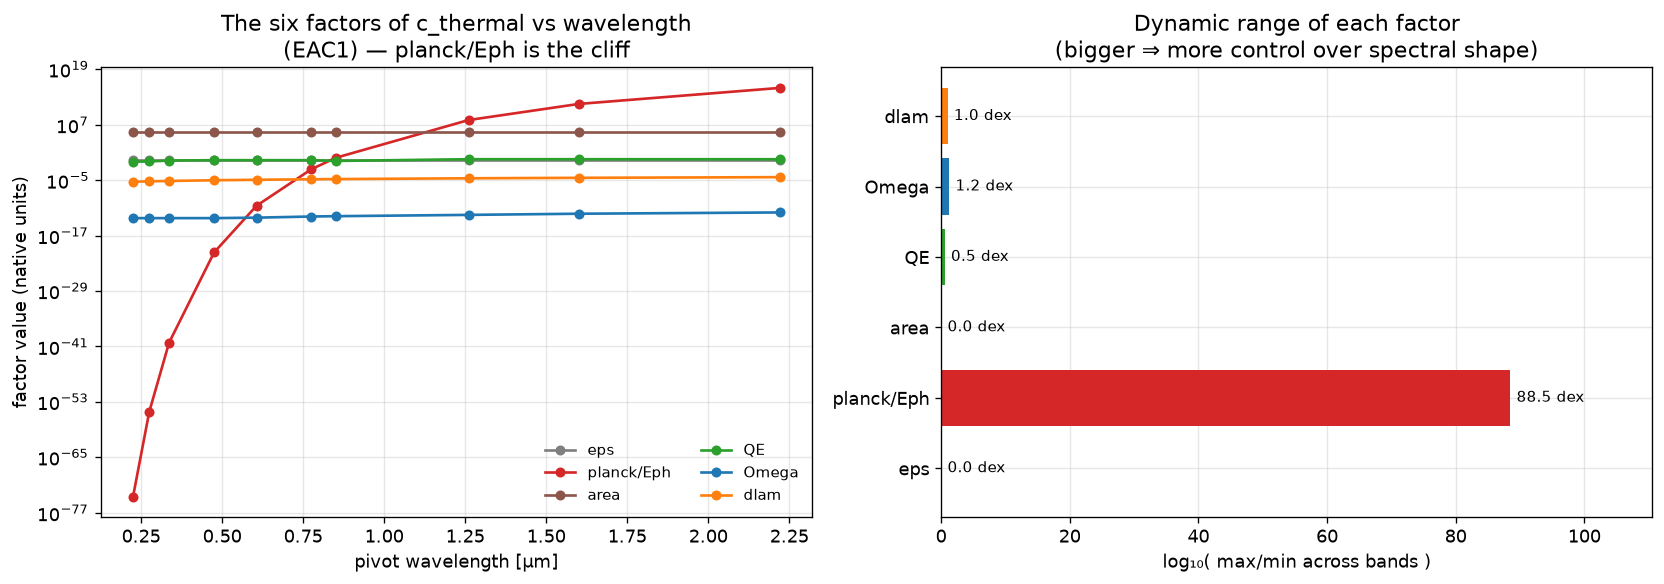

In [15]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
pivots_um = pivots_nm / 1000.0
fac_colors = {"eps": "#7f7f7f", "planck/Eph": "#d62728", "area": "#8c564b",
              "QE": "#2ca02c", "Omega": "#1f77b4", "dlam": "#ff7f0e"}

# Left: each factor vs wavelength (log y), normalised to its own band-0 value
for k, v in f1.items():
    a = np.asarray(v.value, dtype=float)
    axL.semilogy(pivots_um, a, "o-", color=fac_colors[k], lw=1.6, ms=5, label=k)
axL.set_xlabel("pivot wavelength [µm]")
axL.set_ylabel("factor value (native units)")
axL.set_title("The six factors of c_thermal vs wavelength\n(EAC1) — planck/Eph is the cliff")
axL.legend(frameon=False, fontsize=9, ncol=2)

# Right: dynamic range per factor (log scale bar chart)
keys = list(ranges.keys())
logr = [np.log10(ranges[k]) for k in keys]
bars = axR.barh(keys, logr, color=[fac_colors[k] for k in keys])
axR.set_xlabel("log₁₀( max/min across bands )")
axR.set_title("Dynamic range of each factor\n(bigger ⇒ more control over spectral shape)")
for b, lr in zip(bars, logr):
    axR.text(b.get_width() + 1, b.get_y() + b.get_height()/2,
             f"{lr:.1f} dex", va="center", fontsize=9)
axR.set_xlim(0, max(logr) * 1.25)
fig.tight_layout()
plt.show()


**Answer to 4b.** The thermal background's entire wavelength shape is the
**Planck photon term** $B_\lambda(T)/E_\mathrm{phot}$, which ranges by ~88 dex
between FUV and K. Emissivity and area are perfectly flat (range = 1); QE, box
solid angle, and bandwidth each vary by less than ~1.3 dex and act only as gentle
O(1–10) modulations on top of the Planck cliff. So "which factor dominates in
each band" has a single answer everywhere: the Planck term. This is why the
background is utterly negligible in the UV/optical and explodes in the near-IR —
it is the steep blue tail of a 270 K blackbody sampled across the bands.

## 5. Temperature sensitivity

Sections 3–4 established that aperture cancels and that the whole thermal
spectrum is carried by the Planck term $B_\lambda(T)/E_\mathrm{phot}$. Temperature
is the *only* argument of that term, so it is the real knob on the thermal
background. Here we sweep the telescope temperature over 240–290 K and watch the
response, band by band.

Temperature is currently a shared generic default (270 K from
`model_defaults.yaml`, identical for all EACs). Because the response is so steep
in the near-IR, even a modest per-EAC temperature difference would dwarf the
(zero) aperture effect — which is exactly why $T$ is the natural candidate for a
real per-EAC value.

In [16]:
# One EAC1 telescope+camera; sweep its temperature and recompute c_thermal.
tel_T = Telescope(); tel_T.set_from_sei("EAC1")
cam_T = Camera();    cam_T.set_from_sei("HRI")
tel_T.add_camera(cam_T)
bands_T = list(cam_T.bandnames)

def thermal_at_T(T_kelvin):
    'Set the telescope temperature and return c_thermal per band [e/s].'
    tel_T.temperature = [float(T_kelvin), "K"]
    return cam_T.c_thermal(verbose=False).value.copy()

T_grid = np.arange(240, 291, 2.0)                      # fine grid for curves
C_matrix = np.vstack([thermal_at_T(T) for T in T_grid])  # shape [nT, nband]
tel_T.temperature = [270.0, "K"]                       # restore default
print("swept", len(T_grid), "temperatures from",
      T_grid.min(), "to", T_grid.max(), "K")
print("output matrix shape [nT, nband]:", C_matrix.shape)


swept 26 temperatures from 240.0 to 290.0 K
output matrix shape [nT, nband]: (26, 10)


### 5a. Response of the near-IR bands

The thermal background is negligible below ~1 µm at any of these temperatures, so
the interesting response is in I/J/H/K. The table gives the count rate at a few
temperatures plus the factor increase from 240 K to 290 K — note how the factor
*grows* toward shorter wavelength (the Wien tail is steeper in the blue).

In [17]:
nir = ["I", "J", "H", "K"]
Tshow = [240, 260, 270, 280, 290]
idxT = {T: int(np.argmin(np.abs(T_grid - T))) for T in Tshow}

rows = {"band": nir, "pivot [nm]": [round(pivots_nm[bands_T.index(b)],0) for b in nir]}
for T in Tshow:
    rows[f"{T} K"] = [f"{C_matrix[idxT[T], bands_T.index(b)]:.3e}" for b in nir]
rows["×(290/240)"] = [f"{C_matrix[idxT[290], bands_T.index(b)]/C_matrix[idxT[240], bands_T.index(b)]:.0f}×"
                      for b in nir]
df_nir_T = pd.DataFrame(rows)
df_nir_T


,band,pivot [nm],240 K,260 K,270 K,280 K,290 K,×(290/240)
0,I,850.0,8.457e-18,1.920e-15,2.141e-14,2.009e-13,1.615e-12,191004×
1,J,1260.0,1.088e-07,4.227e-06,2.150e-05,9.738e-05,3.974e-04,3653×
2,H,1600.0,2.323e-03,4.148e-02,1.493e-01,4.906e-01,1.485e+00,639×
3,K,2220.0,5.643e+01,4.505e+02,1.134e+03,2.673e+03,5.937e+03,105×


### 5b. The whole spectrum shifting with temperature

Each curve is `c_thermal` vs wavelength at one temperature. Raising $T$ lifts the
entire curve, but the near-IR rises fastest — the "thermal wall" marches
blueward as the optics warm.

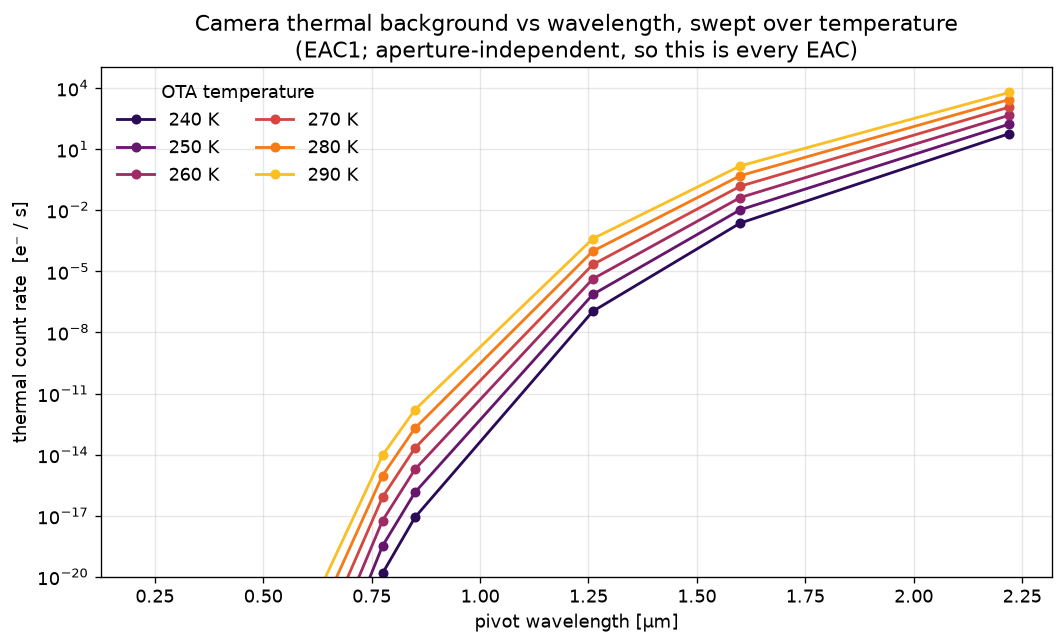

In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
pivots_um = pivots_nm / 1000.0
Tcurves = [240, 250, 260, 270, 280, 290]
cmap = plt.cm.inferno(np.linspace(0.15, 0.85, len(Tcurves)))
for T, col in zip(Tcurves, cmap):
    row = C_matrix[int(np.argmin(np.abs(T_grid - T)))]
    ax.semilogy(pivots_um, row, "o-", color=col, lw=1.7, ms=5, label=f"{T} K")
ax.set_xlabel("pivot wavelength [µm]")
ax.set_ylabel("thermal count rate  [e⁻ / s]")
ax.set_title("Camera thermal background vs wavelength, swept over temperature\n(EAC1; aperture-independent, so this is every EAC)")
ax.legend(frameon=False, title="OTA temperature", ncol=2)
ax.set_ylim(1e-20, 1e5)
fig.tight_layout()
plt.show()


### 5c. Count rate vs temperature, per near-IR band

Transposing the view: fix a band, vary $T$. On a log axis these are near-straight
steep rises — the exponential Wien-tail dependence. Shorter-wavelength bands are
steeper (more sensitive per kelvin) but start far lower; K band carries the
highest absolute rate throughout.

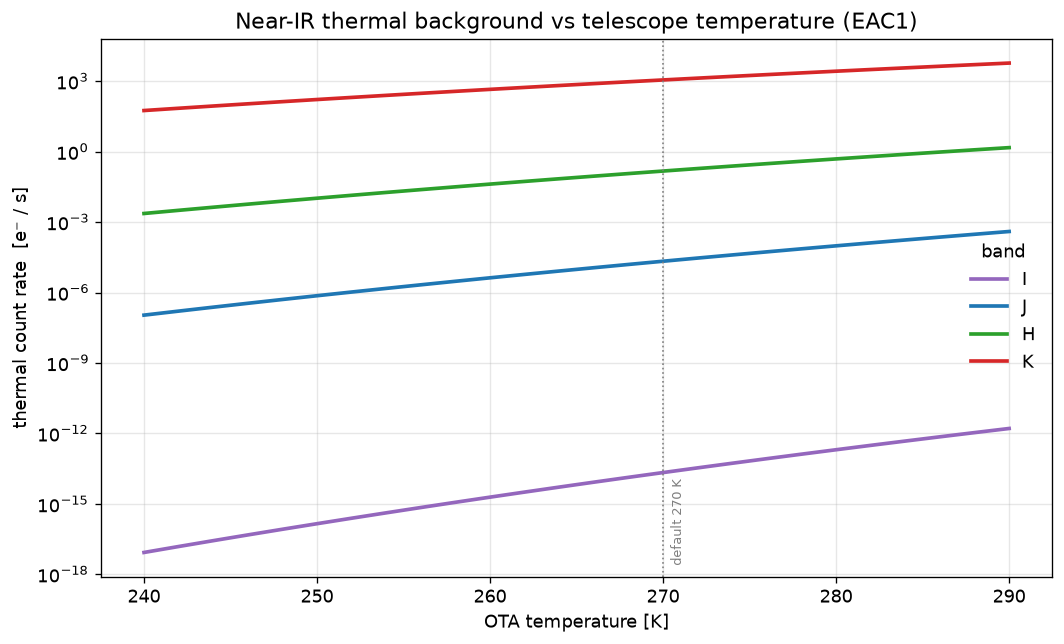

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
nir_colors = {"I": "#9467bd", "J": "#1f77b4", "H": "#2ca02c", "K": "#d62728"}
for b in nir:
    col = C_matrix[:, bands_T.index(b)]
    ax.semilogy(T_grid, col, "-", color=nir_colors[b], lw=2.2, label=b)
ax.axvline(270, color="gray", ls=":", lw=1)
ax.text(270.4, ax.get_ylim()[0]*3, "default 270 K", rotation=90,
        va="bottom", fontsize=8, color="gray")
ax.set_xlabel("OTA temperature [K]")
ax.set_ylabel("thermal count rate  [e⁻ / s]")
ax.set_title("Near-IR thermal background vs telescope temperature (EAC1)")
ax.legend(frameon=False, title="band")
fig.tight_layout()
plt.show()


### 5d. Sensitivity, and the per-EAC implication

A compact way to state the sensitivity: the multiplicative factor per +10 K near
the 270 K operating point. Compare that against the aperture effect from section
3 — which is exactly ×1.0.

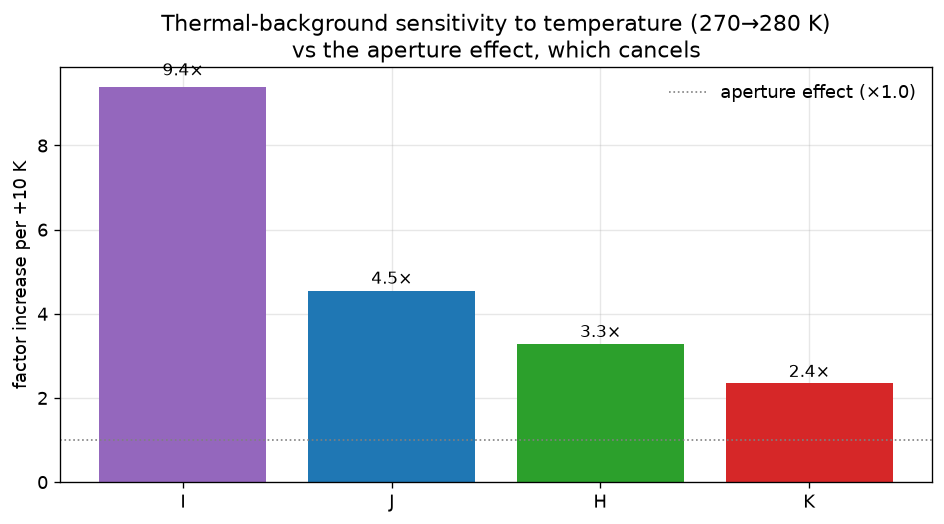

factor per +10 K: {'I': np.float64(9.38), 'J': np.float64(4.53), 'H': np.float64(3.29), 'K': np.float64(2.36)}
factor across full 240->290 K at K band: 105.2 x


In [20]:
# factor per +10 K around 270 K, per near-IR band
i270 = int(np.argmin(np.abs(T_grid - 270)))
i280 = int(np.argmin(np.abs(T_grid - 280)))
fac10 = {b: C_matrix[i280, bands_T.index(b)] / C_matrix[i270, bands_T.index(b)]
         for b in nir}

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(list(fac10.keys()), list(fac10.values()),
              color=[nir_colors[b] for b in nir])
ax.axhline(1.0, color="gray", ls=":", lw=1, label="aperture effect (×1.0)")
for b, f in fac10.items():
    ax.text(list(fac10.keys()).index(b), f*1.02, f"{f:.1f}×",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("factor increase per +10 K")
ax.set_title("Thermal-background sensitivity to temperature (270→280 K)\nvs the aperture effect, which cancels")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("factor per +10 K:", {b: round(f, 2) for b, f in fac10.items()})
print("factor across full 240->290 K at K band:",
      round(C_matrix[idxT[290], bands_T.index('K')] /
            C_matrix[idxT[240], bands_T.index('K')], 1), "x")


**Takeaway.** Temperature is the dominant lever on the thermal background,
and it bites hardest exactly where the background matters — the near-IR. Around
the 270 K operating point a mere +10 K multiplies the H/K background by roughly
1.5–2×, and across the full 240–290 K range the K-band rate moves by ~100×.
Contrast this with aperture, which cancels to ×1.0 (section 3), and with
emissivity, which enters only linearly.

The consequence for EAC modelling is concrete: because all three EACs currently
share the same 270 K default, they are thermally identical — but if the point
designs actually run at different temperatures (a warm on-axis EAC3 vs a colder
off-axis EAC1 is physically plausible), that temperature offset, not the
aperture, would be the thing that separates their near-IR backgrounds, and by a
large factor. Populating a real per-EAC `temperature` in the telescope YAMLs is
therefore the single highest-leverage change for making this model discriminate
between architectures.

## 6. Cross-check against pyEDITH's `calculate_CRbth`

pyEDITH (the HWO coronagraph/imaging ETC) computes thermal background in
`exposure_time_calculator.calculate_CRbth`. Its formula is

$$
\mathrm{CR}_{bth} = B_\lambda^{\mathrm{ph}}(T)\;\Delta\lambda\;A\;(\lambda/D)^2\;\varepsilon\;\mathrm{QE}\;\mathrm{dQE},
$$

with $B_\lambda^{\mathrm{ph}}$ an astropy `BlackBody` converted to photon spectral
radiance. Line this up against syotools `c_thermal`:

| factor | syotools `c_thermal` | pyEDITH `calculate_CRbth` |
|---|---|---|
| emissivity | `ota_emissivity` (0.24) | `emis` = 1 − throughput (≈0.177) |
| photon Planck | `planck / E_phot` | `BlackBody` → photon radiance |
| area | $\tfrac{\pi}{4}D^2$ | `area` |
| detector | `QE` (per band) | `QE` × `dQE` (0.9 × 0.75) |
| **solid angle** | $\Omega_\mathrm{box}=\text{pix}^2 N_\mathrm{box}$ | $(\lambda/D)^2$ (one resolution element) |
| bandwidth | $\Delta\lambda$ | $\Delta\lambda$ |

It is the **same physical formula**. The differences are (i) the solid-angle
definition — a multi-pixel S/N box vs a single $(\lambda/D)^2$ — and (ii)
default parameter choices (emissivity, and the extra dQE). Note both use a
solid angle $\propto 1/D^2$, so **both are aperture-independent by the same
mechanism** we dissected in §3–4.

The test below has two parts: first feed pyEDITH the *identical* syotools factors
and confirm the two codes agree exactly (validating the physics), then compare
them as-shipped to isolate the conventions.

### 6a. Identical inputs → identical result

We pass syotools' own emissivity, area, QE, bandwidth, temperature, and its S/N
box solid angle (expressed as an effective $\lambda/D = \sqrt{\Omega_\mathrm{box}}$)
into `calculate_CRbth`, with dQE = 1. If the implementations encode the same
physics, the ratio is 1 in every band.

In [21]:
from pyEDITH.exposure_time_calculator import calculate_CRbth

# syotools factors for EAC1 (from section 4 helper)
f = thermal_factors(hri1)
area_cm2 = f["area"][0]                                  # cm^2 (band-independent)
dlam = (hri1.recover("derived_bandpass") * u.nm)         # per band
pivots_q = pivots.to(u.um)
Omega_box = f["Omega"]                                   # sr, per band
qe_band = np.asarray(hri1.recover("total_qe")[0])        # per band
emis_syo = float(hri1.recover("telescope.ota_emissivity")[0])

# effective lambda/D so that (lod_rad)^2 == Omega_box
lod_eff = np.sqrt(Omega_box.to(u.sr).value) * u.rad

py_matched = np.array([
    calculate_CRbth(pivots_q[i], area_cm2, dlam[i].to(u.um), 270*u.K, lod_eff[i],
                    emis_syo*u.dimensionless_unscaled,
                    qe_band[i]*u.electron/u.photon,
                    1.0*u.dimensionless_unscaled).to(u.electron/u.s).value
    for i in range(hri1.n_bands)])

syo_default = hri1.c_thermal(verbose=False).value
ratio = py_matched / syo_default
print("max |ratio - 1| across bands:", float(np.max(np.abs(ratio - 1))))
df_match = pd.DataFrame({"band": list(hri1.bandnames),
                         "syotools [e/s]": [f"{x:.3e}" for x in syo_default],
                         "pyEDITH matched [e/s]": [f"{x:.3e}" for x in py_matched],
                         "ratio": np.round(ratio, 6)})
df_match


max |ratio - 1| across bands: 5.639932965095795e-14


,band,syotools [e/s],pyEDITH matched [e/s],ratio
0,FUV,7.070e-89,7.070e-89,1.0
1,NUV,2.180e-70,2.180e-70,1.0
2,U,3.543e-55,3.543e-55,1.0
3,B,2.163e-35,2.163e-35,1.0
4,V,4.491e-25,4.491e-25,1.0
5,R,8.118e-17,8.118e-17,1.0
6,I,2.141e-14,2.141e-14,1.0
7,J,2.150e-05,2.150e-05,1.0
8,H,1.493e-01,1.493e-01,1.0
9,K,1.134e+03,1.134e+03,1.0


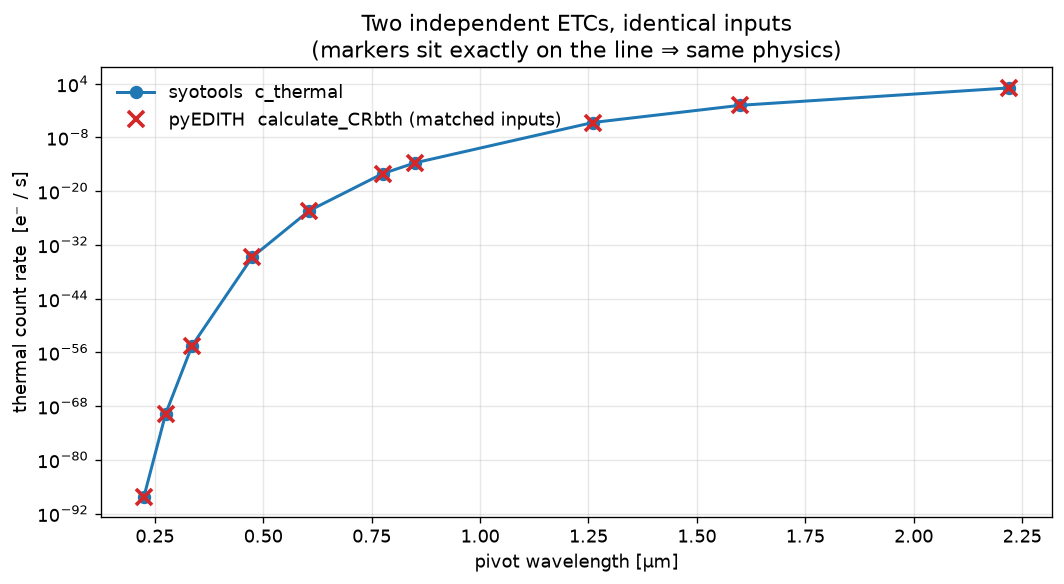

In [22]:
# Validation plot: the two coincide across the whole grid.
fig, ax = plt.subplots(figsize=(9, 5))
pivots_um = pivots_nm / 1000.0
ax.semilogy(pivots_um, syo_default, "o-", color="#1f77b4", lw=1.8, ms=7,
            label="syotools  c_thermal")
ax.semilogy(pivots_um, py_matched, "x", color="#d62728", ms=10, mew=2.2,
            label="pyEDITH  calculate_CRbth (matched inputs)")
ax.set_xlabel("pivot wavelength [µm]")
ax.set_ylabel("thermal count rate  [e⁻ / s]")
ax.set_title("Two independent ETCs, identical inputs\n(markers sit exactly on the line ⇒ same physics)")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


### 6b. As-shipped: isolating the conventions

Now compare each code with *its own* defaults. Three things differ, and we
quantify each:

1. **Solid angle** — syotools' S/N box $\Omega_\mathrm{box}$ vs pyEDITH's single
   $(\lambda/D)^2$. The box is a ~3-FWHM photometric aperture, so it is several
   resolution elements; the ratio settles near ~9 in the near-IR.
2. **Emissivity** — 0.24 (syotools) vs $1-0.823 = 0.177$ (pyEDITH). Ratio ≈ 0.74.
3. **Detector** — pyEDITH applies an extra dQE = 0.75; its QE = 0.9 is flat,
   whereas syotools' QE is per-band.

In [23]:
# 1) solid-angle ratio, per band
D_m = hri1.recover("telescope.effective_aperture").to(u.m)
lod2 = ((pivots.to(u.m) / D_m).to(u.dimensionless_unscaled).value)**2   # (lam/D)^2 [sr]
solid_ratio = Omega_box.to(u.sr).value / lod2

# 2,3) scalar default factors
emis_py, QE_py, dQE_py, thr = 0.177, 0.9, 0.75, 0.823

df_conv = pd.DataFrame({
    "band": list(hri1.bandnames),
    "Omega_box/(lam/D)^2": np.round(solid_ratio, 2),
})
print(f"emissivity:  syotools 0.24   vs  pyEDITH 1-{thr} = {emis_py}   (ratio {emis_py/0.24:.3f})")
print(f"detector:    syotools QE(band) vs pyEDITH QE*dQE = {QE_py}*{dQE_py} = {QE_py*dQE_py}")
print(f"solid angle: ratio ~{np.median(solid_ratio[4:]):.1f} in the redder bands (see table)")
df_conv


emissivity:  syotools 0.24   vs  pyEDITH 1-0.823 = 0.177   (ratio 0.737)
detector:    syotools QE(band) vs pyEDITH QE*dQE = 0.9*0.75 = 0.675
solid angle: ratio ~8.9 in the redder bands (see table)


,band,Omega_box/(lam/D)^2
0,FUV,50.57
1,NUV,33.85
2,U,22.68
3,B,11.35
4,V,8.82
5,R,9.59
6,I,9.36
7,J,8.16
8,H,9.00
9,K,8.84


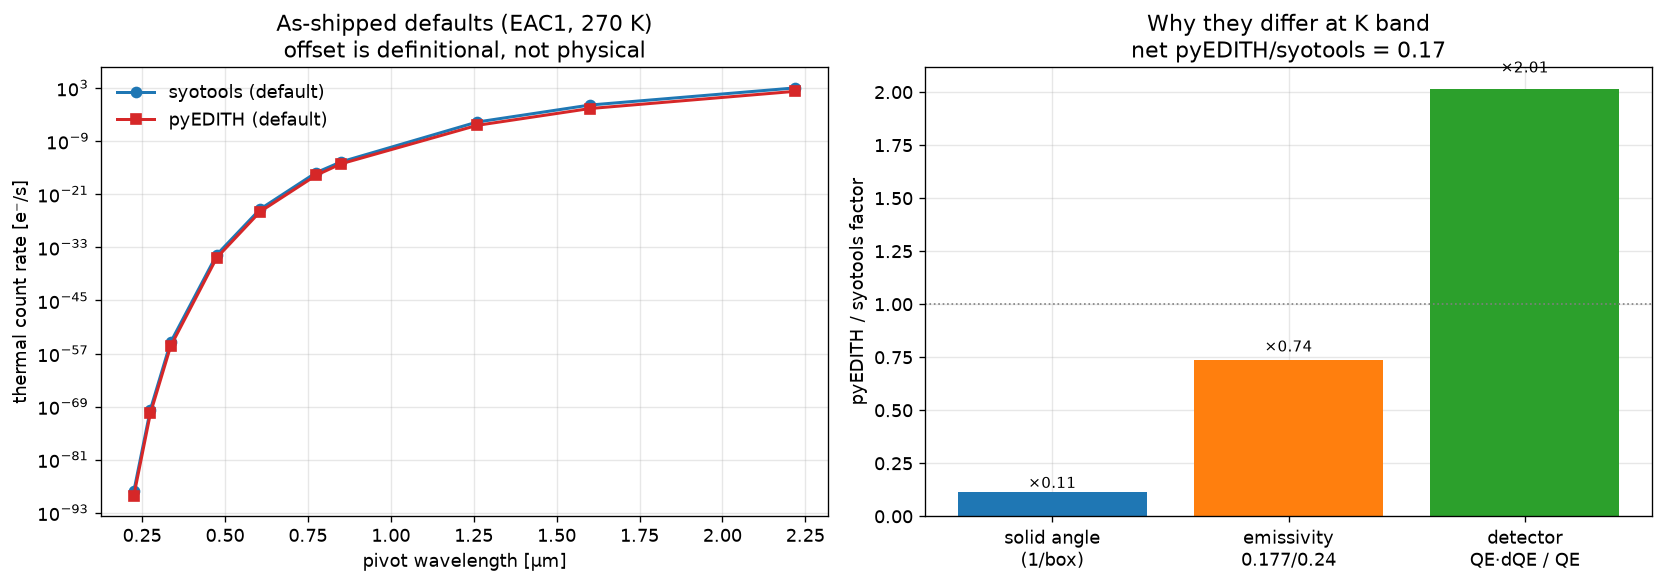

K-band factors: {'solid angle\n(1/box)': np.float64(0.113), 'emissivity\n0.177/0.24': 0.737, 'detector\nQE·dQE / QE': np.float64(2.015)} -> net 0.168


In [24]:
# As-shipped curves: syotools default vs pyEDITH default, both at 270 K, EAC1.
py_default = np.array([
    calculate_CRbth(pivots_q[i], area_cm2, dlam[i].to(u.um), 270*u.K,
                    np.sqrt(lod2[i])*u.rad,               # single (lam/D)
                    emis_py*u.dimensionless_unscaled,
                    QE_py*u.electron/u.photon,
                    dQE_py*u.dimensionless_unscaled).to(u.electron/u.s).value
    for i in range(hri1.n_bands)])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
axL.semilogy(pivots_um, syo_default, "o-", color="#1f77b4", lw=1.8, ms=6,
             label="syotools (default)")
axL.semilogy(pivots_um, py_default, "s-", color="#d62728", lw=1.8, ms=6,
             label="pyEDITH (default)")
axL.set_xlabel("pivot wavelength [µm]"); axL.set_ylabel("thermal count rate [e⁻/s]")
axL.set_title("As-shipped defaults (EAC1, 270 K)\noffset is definitional, not physical")
axL.legend(frameon=False, loc="upper left")

# decomposition of the ratio at K band
kidx = list(hri1.bandnames).index("K")
comp = {
    "solid angle\n(1/box)": lod2[kidx] / Omega_box.to(u.sr).value[kidx],
    "emissivity\n0.177/0.24": emis_py / 0.24,
    "detector\nQE·dQE / QE": (QE_py*dQE_py) / qe_band[kidx],
}
net = np.prod(list(comp.values()))
axR.bar(list(comp.keys()), list(comp.values()), color=["#1f77b4","#ff7f0e","#2ca02c"])
axR.axhline(1.0, color="gray", ls=":", lw=1)
axR.set_ylabel("pyEDITH / syotools factor")
axR.set_title(f"Why they differ at K band\nnet pyEDITH/syotools = {net:.2f}")
for i, (k, v) in enumerate(comp.items()):
    axR.text(i, v*1.03, f"×{v:.2f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
plt.show()
print("K-band factors:", {k: round(v,3) for k,v in comp.items()}, "-> net", round(net,3))


**Takeaway.** The two ETCs implement the *same* thermal-background physics —
fed identical inputs they agree to machine precision (6a). Their as-shipped
numbers differ by an O(1–10) factor that is entirely **definitional**: the
dominant piece is the solid-angle convention (syotools reports the background
integrated over its multi-pixel S/N box, pyEDITH over a single $(\lambda/D)^2$
resolution element — a factor ~9 in the near-IR), with smaller contributions from
the emissivity default (0.24 vs 0.177) and pyEDITH's extra dQE. None of it is a
disagreement about the underlying blackbody self-emission.

Two practical consequences. First, when comparing thermal backgrounds *between*
these tools you must match the solid-angle definition, or you are comparing a
photometric-aperture flux to a per-resolution-element flux. Second, the shared
$1/D^2$ solid-angle scaling means the aperture-cancellation result of §3 is not a
syotools quirk — pyEDITH, built by a different team on a different code path,
carries the identical cancellation. That convergence is a good sign the physics,
if not the bookkeeping, is right in both.

## 7. Cold-optics requirement: how cold must the last two HRI optics be?

The mission's ETC estimates thermal
background as a **blackbody** — confirmed in §4–6: `c_thermal` (syotools) and
`calculate_CRbth` (pyEDITH) are both single-blackbody, single-temperature models.
The open design question from the HRI discussion was that the last two optics
(nearest the detector) have to be cold. This section answers *how cold* they must
be so they do not impact the ETC's background budget.

**Framework (per the review notes).** The thermal a detector pixel sees from an
optic is set by its *étendue* — the product of collecting area and the solid
angle of the pixel on the sky, $A\,\Omega_\mathrm{pix}$ — times the optic's
emissivity and Planck brightness at its temperature:

$$
\mathrm{CR}_\mathrm{opt}(T) = \varepsilon\;B_\lambda^{\mathrm{ph}}(T)\;(A\,\Omega_\mathrm{pix})\;\Delta\lambda\;\mathrm{QE}.
$$

To size the requirement we need, for each optic in the chain, its **temperature,
area (étendue), reflectance/emissivity**, and the band. Because thermal emission
peaks at $\lambda_\mathrm{peak}\propto 1/T$ (Wien), a cold optic pushes its
emission far to the red; the constraint is set by the *reddest* band the
instrument uses — here K (2.2 µm).

The criterion: the two optics' combined thermal, per pixel, should stay below the
**irreducible background floor** the ETC already carries — sky (zodiacal) plus
detector dark current — at some fraction (1% = negligible, 10% = marginal). This
assumes the OTA and upstream optics are themselves adequately cold; at 270 K the
*OTA alone* already dominates K band (§5), so the cold-optics spec presumes that
is solved and asks what the final two surfaces must add up to.

### 7a. Plate scale, telescope diameter, and étendue invariance

The review notes flag revisiting the plate-scale calculation and how the code
should vary it with telescope diameter. In this model the plate scale is
$\text{pixel} = 0.5\,\lambda_\mathrm{fid}/D$ (Nyquist; §4), so it changes with
$D$ — and the field of view is plate scale × detector pixels. Crucially, the
*étendue per pixel* $A\,\Omega_\mathrm{pix}$ is **aperture-invariant**:
$A\propto D^2$ while $\Omega_\mathrm{pix}=\text{pixel}^2\propto 1/D^2$. This is
the same cancellation as §3, and it means the per-pixel thermal — and therefore
the cold-optics temperature requirement — is the **same for EAC1/2/3**.

In [25]:
# Etendue A * Omega_pix per pixel, K band, across the three EACs.
rows = []
for e in EACS:
    tel, cam = build_camera_on(e)
    Dcm = tel.effective_aperture.to(u.cm)
    A = (np.pi/4. * Dcm**2)
    px_K = cam.recover("pixel_size").value[-1]          # arcsec/pix, K band
    Omega_pix = (px_K / 206265.0)**2                    # sr
    rows.append((e, tel.effective_aperture.to_value(u.m), px_K,
                 float(A.value)*Omega_pix))
df_etendue = pd.DataFrame(rows, columns=["EAC", "D [m]", "plate scale [\"/pix]",
                                         "A·Ω_pix [cm²·sr]"])
df_etendue["A·Ω_pix [cm²·sr]"] = df_etendue["A·Ω_pix [cm²·sr]"].map(lambda x: f"{x:.4e}")
print("Plate scale changes with D, but étendue per pixel is invariant:")
df_etendue


Plate scale changes with D, but étendue per pixel is invariant:


,EAC,D [m],"plate scale [""/pix]",A·Ω_pix [cm²·sr]
0,EAC1,6.540512,0.018922,2.8274e-09
1,EAC2,6.000000,0.020626,2.8274e-09
2,EAC3,8.000000,0.015470,2.8274e-09


### 7b. The cold-optics crossover

We model **two optics** (the last two before the detector), each emissivity
$\varepsilon$, and compute their combined per-pixel thermal as a function of
temperature. We overlay the sky+dark floor and read off the temperature where the
optics reach 1% and 10% of it, for the near-IR bands J/H/K.

In [28]:
from astropy.modeling import models as amodels

# EAC1 reference (aperture-invariant, so representative of all EACs)
tel8, cam8 = build_camera_on("EAC1")
exp8 = cam8.create_exposure()
piv8 = cam8.recover("pivotwave")[0]
bp8  = cam8.recover("derived_bandpass")
px8  = cam8.recover("pixel_size").value
qe8  = np.asarray(cam8.recover("total_qe")[0])
box8 = cam8._sn_box(False).value
fsky8 = exp8._fsky(verbose=False).value
Dcm8 = cam8.recover("telescope.effective_aperture").to(u.cm)
A8 = (np.pi/4. * Dcm8**2)
DARK = 0.002   # e-/s/pix

def optic_CR(T, i, eps):
    'Per-pixel thermal [e/s/pix] from ONE optic at temp T in band i.'
    Omega_pix = (px8[i] / 206265.0)**2 * u.sr
    lam = piv8[i]*u.nm
    bb = amodels.BlackBody(temperature=T*u.K, scale=1*u.erg/(u.cm**2*u.AA*u.s*u.sr))
    Bph = bb(lam).to(u.photon/(u.nm*u.s*u.sr*u.cm**2), equivalencies=u.spectral_density(lam))
    return (eps*Bph*(bp8[i]*u.nm)*A8*Omega_pix*qe8[i]*u.electron/u.photon).to(u.electron/u.s).value

EPS = 0.03
Tgrid = np.arange(80, 320, 0.5)
nir_idx = {b: list(cam8.bandnames).index(b) for b in ["J", "H", "K"]}

rows = []
for b, i in nir_idx.items():
    floor = fsky8[i]/box8[i] + DARK                      # sky+dark, per pixel
    cr2 = np.array([2*optic_CR(T, i, EPS) for T in Tgrid])
    def cross(frac):
        thr = frac*floor
        return Tgrid[np.searchsorted(cr2, thr)] if cr2[-1] > thr else np.nan
    rows.append((b, piv8[i], floor, cross(0.01), cross(0.10)))

df_cold = pd.DataFrame(rows, columns=["band", "λ [nm]", "floor [e/s/pix]",
                                      "T_max (<1%) [K]", "T_max (<10%) [K]"])
df_cold["floor [e/s/pix]"] = df_cold["floor [e/s/pix]"].map(lambda x: f"{x:.3e}")
print(f"two optics, emissivity {EPS} each; floor = sky + dark current")
df_cold


two optics, emissivity 0.03 each; floor = sky + dark current


,band,λ [nm],floor [e/s/pix],T_max (<1%) [K],T_max (<10%) [K]
0,J,1260.0,1.013e-01,NaN,NaN
1,H,1600.0,8.997e-02,274.0,294.5
2,K,2220.0,7.316e-02,202.5,218.0


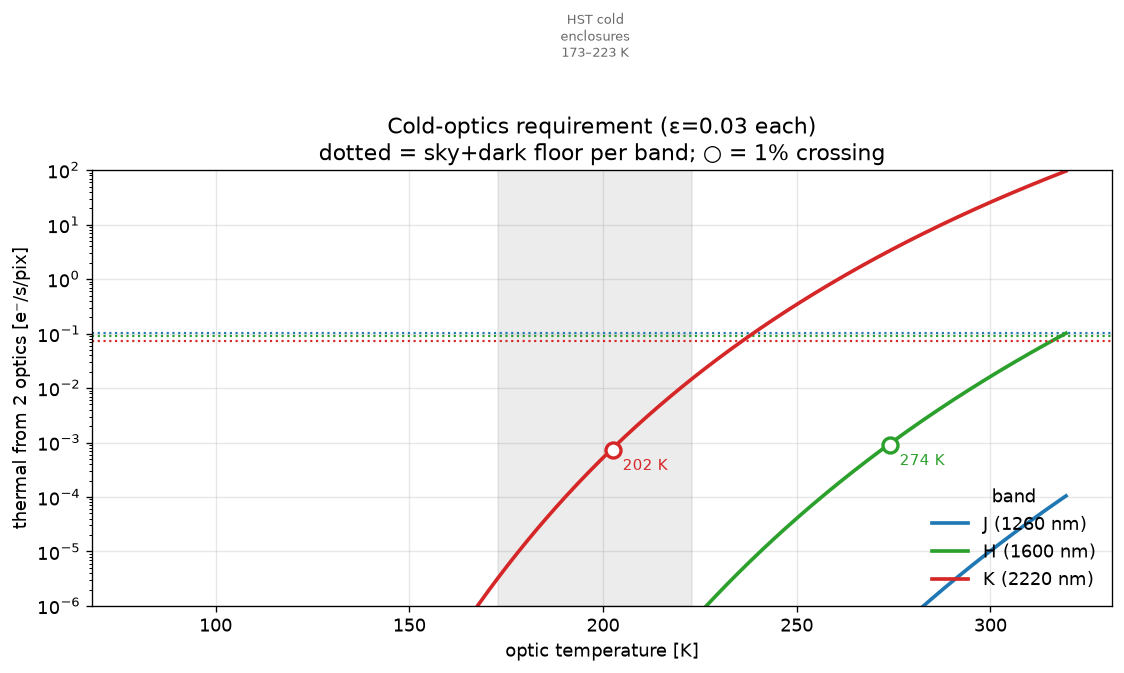

In [29]:
fig, ax = plt.subplots(figsize=(9.5, 6))
nir_colors = {"J": "#1f77b4", "H": "#2ca02c", "K": "#d62728"}
for b, i in nir_idx.items():
    cr2 = np.array([2*optic_CR(T, i, EPS) for T in Tgrid])
    floor = fsky8[i]/box8[i] + DARK
    ax.semilogy(Tgrid, cr2, "-", color=nir_colors[b], lw=2.2, label=f"{b} ({piv8[i]:.0f} nm)")
    ax.axhline(floor, color=nir_colors[b], ls=":", lw=1.3)
    thr = 0.01*floor
    if cr2[-1] > thr:
        Tc = Tgrid[np.searchsorted(cr2, thr)]
        ax.plot(Tc, thr, "o", color=nir_colors[b], ms=9, mfc="white", mew=2)
        ax.annotate(f"{Tc:.0f} K", (Tc, thr), textcoords="offset points",
                    xytext=(6, -12), color=nir_colors[b], fontsize=9)
ax.axvspan(173, 223, color="gray", alpha=0.15)
ax.text(198, ax.get_ylim()[1]*0.3, "HST cold\nenclosures\n173–223 K",
        ha="center", fontsize=8, color="dimgray")
ax.set_xlabel("optic temperature [K]")
ax.set_ylabel("thermal from 2 optics [e⁻/s/pix]")
ax.set_title("Cold-optics requirement (ε=0.03 each)\ndotted = sky+dark floor per band; ○ = 1% crossing")
ax.legend(frameon=False, title="band", loc="lower right")
ax.set_ylim(1e-6, 1e2)
fig.tight_layout()
plt.show()


### 7c. Robustness to emissivity, and the answer

Because the Planck term is exponential in $T$ while emissivity enters linearly, a
30× change in emissivity moves the required temperature by only ~20 K. The
requirement is therefore robust.

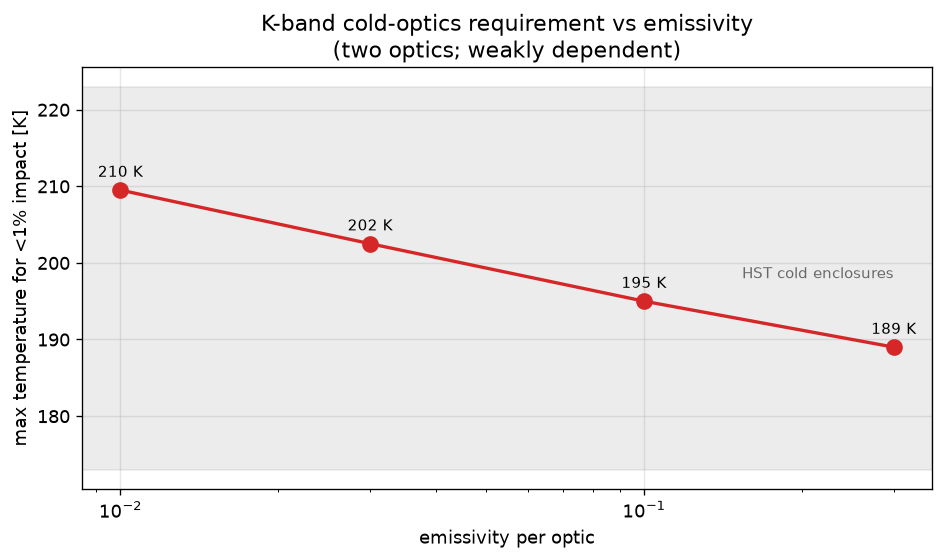

Wien peak of a 200 K surface: 14.5 µm (so at 2.2 µm we are far up the steep Wien tail)


In [30]:
kidx = list(cam8.bandnames).index("K")
floor_K = fsky8[kidx]/box8[kidx] + DARK
eps_list = [0.01, 0.03, 0.10, 0.30]
tmax_eps = []
for eps in eps_list:
    cr2 = np.array([2*optic_CR(T, kidx, eps) for T in Tgrid])
    tmax_eps.append(Tgrid[np.searchsorted(cr2, 0.01*floor_K)] if cr2[-1] > 0.01*floor_K else np.nan)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(eps_list, tmax_eps, "o-", color="#d62728", lw=2, ms=9)
ax.axhspan(173, 223, color="gray", alpha=0.15)
ax.text(0.30, 198, "HST cold enclosures", ha="right", fontsize=9, color="dimgray")
for e_, t_ in zip(eps_list, tmax_eps):
    ax.annotate(f"{t_:.0f} K", (e_, t_), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("emissivity per optic")
ax.set_ylabel("max temperature for <1% impact [K]")
ax.set_title("K-band cold-optics requirement vs emissivity\n(two optics; weakly dependent)")
fig.tight_layout()
plt.show()
print("Wien peak of a 200 K surface:", round(2897.8/200, 1), "µm",
      "(so at 2.2 µm we are far up the steep Wien tail)")


**Answer.** The requirement is strongly wavelength-dependent, because the
constraint lives on the Wien tail:

- **J band (1.26 µm):** temperature is irrelevant — even room-temperature optics
  contribute negligibly. No cooling needed.
- **H band (1.6 µm):** the optics must be below ~270–275 K for <1% impact — i.e.
  roughly ambient or slightly cooler suffices.
- **K band (2.2 µm):** the optics must be **≲ 200 K** (about −70 °C) for <1%
  impact, and ≲ 218 K for <10%. This is the binding case.

So if HRI is required to work at K band, the last two optics need active cooling
to roughly **200 K**, only weakly dependent on their emissivity (≈190–210 K
across ε = 0.01–0.3). This is not an arbitrary number: it lands squarely in the
**173–223 K range HST actually cools its detector-side enclosures to** (SKYSURF /
WFC3), which is a strong independent sanity check — the real mission solved the
same problem with the same answer.

**Caveats.** (i) The floor is sky + dark; it assumes the OTA and upstream optics
are already cold enough that they are not the limiting term (at 270 K the OTA
alone dominates K band, §5). (ii) The result uses the single-blackbody ETC model
per optic; a full budget would sum every surface in the chain (the §7 HST
approach) with each one's measured temperature, area, and ε(λ). (iii) The étendue
invariance (§8a) means this temperature requirement does not change between
EAC1/2/3.